# Вычислительное музыковедение: Модели и методы Music Data Mining

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Лабораторная работа №3.  Классификация музыкальных данных методами классического МО

### Работа с данными

!pip install datasets

In [2]:
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.5 MB/s eta 0:00:00


Полезные ссылки:
1. http://ismir2001.ismir.net/pdf/tzanetakis.pdf
2. https://huggingface.co/datasets/marsyas/gtzan

In [3]:
from datasets import load_dataset

dataset = load_dataset("marsyas/gtzan")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/datasets/load.py:1461: FutureWarning: The repository for marsyas/gtzan contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/marsyas/gtzan
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.war

Generating train split: 0 examples [00:00, ? examples/s]

GTZAN is a dataset for musical genre classification of audio signals. The dataset consists of 1,000 audio tracks, each of 30 seconds long. It contains 10 genres, each represented by 100 tracks. The tracks are all 22,050Hz Mono 16-bit audio files in WAV format. The genres are: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, and rock.

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'genre'],
        num_rows: 999
    })
})

In [5]:
dataset['train'][998]

{'file': '/root/.cache/huggingface/datasets/downloads/extracted/5022b0984afa7334ff9a3c60566280b08b5179d4ac96a628052bada7d8940244/genres/rock/rock.00099.wav',
 'audio': {'path': '/root/.cache/huggingface/datasets/downloads/extracted/5022b0984afa7334ff9a3c60566280b08b5179d4ac96a628052bada7d8940244/genres/rock/rock.00099.wav',
  'array': array([-0.02111816, -0.03451538, -0.03536987, ...,  0.00134277,
          0.00250244, -0.00186157]),
  'sampling_rate': 22050},
 'genre': 9}

In [6]:
num2class = {
    0: 'blues',
    1: 'classical',
    2: 'country',
    3: 'disco',
    4: 'hiphop',
    5: 'jazz',
    6: 'metal',
    7: 'pop',
    8: 'reggae',
    9: 'rock'
}

In [7]:
import IPython.display as ipd

idx = 222

print(dataset['train'][idx]['file'].split('/')[-1]) # num2class[...]
print(num2class.get(dataset['train'][idx]['genre'], 'Unknown')) # num2class[...]
ipd.Audio(dataset['train'][idx]['audio']['array'], rate=dataset['train'][idx]['audio']['sampling_rate'])

country.00022.wav
country


### Классификация

Больше информации: https://scikit-learn.org/stable/modules/classes.html

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


tree_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    random_state=111
)
tree_clf

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=111)

In [9]:
tree_clf.fit([elem['features'] for elem in train_data], [elem['genre'] for elem in train_data])

NameError: name 'train_data' is not defined

#### Как можно посмотреть на решающие правила

In [ ]:
ruls = tree.export_text(tree_clf)
print(ruls)

In [ ]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(tree_clf,
                   feature_names=None,
                   class_names=list(num2class.values()),
                   filled=True)


#### Аналитика результатов

In [ ]:
real_class = [elem['genre'] for elem in test_data]
predict_result = list(tree_clf.predict([elem['features'] for elem in test_data]))

https://scikit-learn.org/stable/modules/model_evaluation.html#accuracy-score

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(real_class, predict_result)

In [ ]:
from sklearn.metrics import recall_score

recall_score(real_class, predict_result, average='micro'), recall_score(real_class, predict_result, average='macro')

In [ ]:
from sklearn.metrics import precision_score

precision_score(real_class, predict_result, average='micro'), precision_score(real_class, predict_result, average='macro')

In [ ]:
from sklearn.metrics import f1_score

f1_score(real_class, predict_result, average='micro'), f1_score(real_class, predict_result, average='macro')

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(real_class, predict_result))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_name = [num2class[i] for i in real_class]
y_pred_name = [num2class[i] for i in predict_result]


plt.rcParams['figure.figsize'] = [10, 10]
cm = confusion_matrix(y_true_name, y_pred_name, labels=list(num2class.values()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(num2class.values()))
disp.plot()
plt.show()

### Задание на лабораторную работу (10 баллов)

1. Произвести подготовку данных (извлечь признаки с помощью open SMILE)
2. Обучить 3 различных классификатора (для каждого классификатора поиграться с гиперпараметрами, 2 эксперимента на классификатор)
3. Расчитать метрики: acc, f-1 и третья - на ваш выбор
4. Для каждого эксперемента произвести анализ confuision matrix
5. В конце создать итоговую таблицу с эксперминетами и результатами. Сделать выводы.
6. Цель - получить метрику классификации выше, чем в примере.

## Извлечение признаков

In [11]:
signal = dataset['train'][idx]['audio']['array']
sr = dataset['train'][idx]['audio']['sampling_rate']

In [12]:
!pip install opensmile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.2/996.2 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.9/66.9 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.9/140.9 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.4/167.4 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iso-639: filename=iso_639-0.4.5-py3-none-any.whl size=168840 sha256=e6cf60c7a4dfe8b65999e353bb5995b5e3335c407ec225713f062a382880c216
  Stored in directory: /root/.cache/pip/wheels/d8/78/cc/5478ca3b1c3f602eae6f8cdbd78f909c0a0bfa0bbcb5c7771f
Successfully built iso-639


In [13]:
import opensmile

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
)
smile.feature_names

['Loudness_sma3',
 'alphaRatio_sma3',
 'hammarbergIndex_sma3',
 'slope0-500_sma3',
 'slope500-1500_sma3',
 'spectralFlux_sma3',
 'mfcc1_sma3',
 'mfcc2_sma3',
 'mfcc3_sma3',
 'mfcc4_sma3',
 'F0semitoneFrom27.5Hz_sma3nz',
 'jitterLocal_sma3nz',
 'shimmerLocaldB_sma3nz',
 'HNRdBACF_sma3nz',
 'logRelF0-H1-H2_sma3nz',
 'logRelF0-H1-A3_sma3nz',
 'F1frequency_sma3nz',
 'F1bandwidth_sma3nz',
 'F1amplitudeLogRelF0_sma3nz',
 'F2frequency_sma3nz',
 'F2bandwidth_sma3nz',
 'F2amplitudeLogRelF0_sma3nz',
 'F3frequency_sma3nz',
 'F3bandwidth_sma3nz',
 'F3amplitudeLogRelF0_sma3nz']

In [14]:
smile.process_signal(
    signal, sr
)

,,Loudness_sma3,alphaRatio_sma3,hammarbergIndex_sma3,slope0-500_sma3,slope500-1500_sma3,spectralFlux_sma3,mfcc1_sma3,mfcc2_sma3,mfcc3_sma3,mfcc4_sma3,...,logRelF0-H1-A3_sma3nz,F1frequency_sma3nz,F1bandwidth_sma3nz,F1amplitudeLogRelF0_sma3nz,F2frequency_sma3nz,F2bandwidth_sma3nz,F2amplitudeLogRelF0_sma3nz,F3frequency_sma3nz,F3bandwidth_sma3nz,F3amplitudeLogRelF0_sma3nz
start,end,,,,,,,,,,,,,,,,,,,,,
0 days 00:00:00,0 days 00:00:00.020000,1.022170,-13.837646,19.467779,0.022693,-0.027534,0.349668,19.095894,23.398077,9.960184,-4.642103,...,0.000000,336.844330,1201.680664,-132.499771,1324.658569,813.927185,-137.460327,2508.428711,594.430481,-140.654846
0 days 00:00:00.010022676,0 days 00:00:00.030022676,0.926593,-13.994546,21.287294,0.022805,-0.024235,0.493799,20.757418,19.545120,9.336352,-0.881383,...,23.431078,345.934814,1196.950439,-63.190964,1317.796509,818.845642,-73.726135,2436.766357,611.715576,-80.156990
0 days 00:00:00.020045351,0 days 00:00:00.040045351,0.794908,-14.093396,22.846529,0.021088,-0.020114,0.695995,23.354574,14.369424,8.856368,2.132916,...,25.966497,362.577240,1146.884155,7.301015,1319.445923,788.014709,-9.652803,2384.275391,614.552002,-20.835981
0 days 00:00:00.030068027,0 days 00:00:00.050068027,0.736859,-16.116556,26.485987,0.022850,-0.015011,0.673433,28.693855,12.026611,10.132930,3.759389,...,27.920822,361.822601,1165.465210,10.187454,1307.851929,819.117188,-9.167827,2349.752686,680.167908,-18.758677
0 days 00:00:00.040090703,0 days 00:00:00.060090703,0.716083,-18.059561,29.910690,0.035115,-0.015959,0.676323,32.420551,11.142451,10.813828,2.856160,...,31.367371,372.233673,1154.952759,11.417629,1334.528320,839.511658,-10.403924,2383.637695,820.009766,-19.239479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0 days 00:00:29.917687075,0 days 00:00:29.937687075,0.374032,-22.473776,27.678305,0.020221,-0.031669,0.224027,35.822865,15.203434,4.193106,6.656746,...,18.448881,911.485168,1243.395020,-6.055143,2055.259521,770.602051,-11.869481,3301.040771,1008.604492,-8.348729
0 days 00:00:29.927709751,0 days 00:00:29.947709751,0.368916,-22.770868,29.878822,0.042164,-0.029324,0.213694,36.390179,15.668056,3.511129,6.515526,...,10.766086,947.835999,1286.986328,-6.924269,2073.125000,780.071533,-10.634455,3335.458740,760.516602,-0.897207
0 days 00:00:29.937732426,0 days 00:00:29.957732426,0.426883,-19.142687,26.953560,0.048654,-0.026556,0.198515,31.165644,14.849351,9.933486,-2.979652,...,7.891603,961.212830,1272.176880,-7.205282,2090.739990,763.210999,-7.878637,3397.715576,689.757141,1.988894


In [15]:
smile = opensmile.Smile()
result = smile.process_signal(
    signal, sr
)
result

,,audspec_lengthL1norm_sma_range,audspec_lengthL1norm_sma_maxPos,audspec_lengthL1norm_sma_minPos,audspec_lengthL1norm_sma_quartile1,audspec_lengthL1norm_sma_quartile2,audspec_lengthL1norm_sma_quartile3,audspec_lengthL1norm_sma_iqr1-2,audspec_lengthL1norm_sma_iqr2-3,audspec_lengthL1norm_sma_iqr1-3,audspec_lengthL1norm_sma_percentile1.0,...,mfcc_sma_de[14]_peakRangeAbs,mfcc_sma_de[14]_peakRangeRel,mfcc_sma_de[14]_peakMeanAbs,mfcc_sma_de[14]_peakMeanMeanDist,mfcc_sma_de[14]_peakMeanRel,mfcc_sma_de[14]_minRangeRel,mfcc_sma_de[14]_meanRisingSlope,mfcc_sma_de[14]_stddevRisingSlope,mfcc_sma_de[14]_meanFallingSlope,mfcc_sma_de[14]_stddevFallingSlope
start,end,,,,,,,,,,,,,,,,,,,,,
0 days,0 days 00:00:30.013333333,2.519101,0.17007,0.657851,0.785257,1.030075,1.346128,0.244818,0.316053,0.56087,0.357733,...,7.10078,0.447964,2.251065,2.252208,-20.0,0.698524,94.000664,47.584961,92.44622,49.175404


In [16]:
result.to_numpy()

array([[ 2.5191014,  0.1700703,  0.6578507, ..., 47.58496  , 92.44622  ,
        49.175404 ]], dtype=float32)

In [17]:
# from tqdm import tqdm

# smile = opensmile.Smile()

# prepared_data = []

# for idx in tqdm(range(len(dataset['train']))):
#     signal = dataset['train'][idx]['audio']['array']
#     sr = dataset['train'][idx]['audio']['sampling_rate']
#     genre = dataset['train'][idx]['genre']
#     features = smile.process_signal(signal, sr).to_numpy()[0]
#     prepared_data.append({
#         'id': idx,
#         'features': features,
#         'genre': genre
#     })


In [18]:
import numpy as np
# Сохранить
file_name = '/content/drive/MyDrive/ВычМуз/ЛР3/smile_features.npy'
#np.save(file_name, prepared_data, allow_pickle=True) # Не забудьте закомментировать, чтобы не перезаписать или еще что.

# Извлечь
data = np.load(file_name, allow_pickle=True)
len(data)

999

In [19]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.3, random_state=111)

In [20]:
len(train_data), len(test_data)

(699, 300)

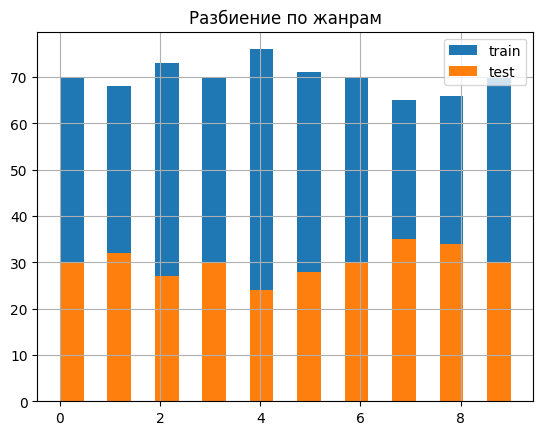

In [21]:
import matplotlib.pyplot as plt

plt.hist([elem['genre'] for elem in train_data], 19, label='train')
plt.hist([elem['genre'] for elem in test_data], 19, label='test')
plt.legend()
plt.title('Разбиение по жанрам')
plt.grid()
plt.show()

In [22]:
import pandas as pd

In [23]:
X_train = []
X_test = []
y_train = []
y_test = []
for el in train_data:
  y_train.append(el['genre'])
  X_train.append(el['features'])

for el in test_data:
  y_test.append(el['genre'])
  X_test.append(el['features'])
train_X = pd.DataFrame(X_train)
train_X

,0,1,2,3,4,5,6,7,8,9,...,6363,6364,6365,6366,6367,6368,6369,6370,6371,6372
0,2.179675,0.607968,0.993974,2.011944,2.199473,2.387266,0.187529,0.187793,0.375321,1.399022,...,6.073265,0.585413,1.808336,1.808020,20.000000,0.554028,91.565796,46.654381,90.799263,42.834282
1,2.494917,0.993972,0.091092,1.212245,1.533471,2.006567,0.321226,0.473097,0.794323,0.820687,...,7.306621,0.532843,2.154247,2.157832,-19.998230,0.621608,102.977219,49.332272,101.190750,50.974510
2,1.920041,0.520254,0.051892,0.187559,0.278627,0.483360,0.091068,0.204733,0.295800,0.112427,...,8.606526,0.559020,1.970847,1.965262,19.982101,0.473829,83.176926,43.532719,77.581833,43.335449
3,2.790253,0.359893,0.509876,1.323680,1.636645,2.035378,0.312965,0.398733,0.711697,0.970508,...,7.576564,0.524441,2.329550,2.327082,19.999855,0.659388,112.687782,56.710335,106.700485,52.969780
4,3.527774,0.332775,0.027452,1.271431,1.999294,2.839279,0.727863,0.839985,1.567848,0.741626,...,7.482171,0.534051,2.139028,2.136880,19.999897,0.604503,92.091530,45.415047,95.604652,49.813129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,3.033883,0.486106,0.236358,0.575194,0.880631,1.459985,0.305437,0.579354,0.884791,0.232547,...,12.243351,0.621412,2.418503,2.421450,-19.999664,0.437970,96.734314,57.098278,95.711075,50.248291
695,4.136610,0.862693,0.077696,1.174778,1.524077,2.031258,0.349299,0.507181,0.856480,0.336125,...,9.648918,0.542542,2.398583,2.395263,19.999317,0.517291,102.537178,56.999298,104.332420,57.032188
696,3.394233,0.051557,0.179444,1.276617,1.716310,2.176405,0.439693,0.460095,0.899788,0.261629,...,8.823512,0.531528,2.340486,2.338472,19.999962,0.640713,97.876366,47.849297,97.171265,53.994011
697,2.815430,0.853650,0.688881,0.883019,1.157240,1.497353,0.274221,0.340113,0.614334,0.433344,...,7.466208,0.631357,1.957358,1.956956,20.000000,0.580242,92.210472,44.763130,92.961761,46.284081


In [24]:
test_X = pd.DataFrame(X_test)
test_X

,0,1,2,3,4,5,6,7,8,9,...,6363,6364,6365,6366,6367,6368,6369,6370,6371,6372
0,0.955446,0.472715,0.994978,0.565551,0.695052,0.830884,0.129501,0.135832,0.265333,0.371937,...,10.404874,0.561028,2.916959,2.909151,19.985634,0.516858,119.057533,58.359348,118.526253,56.866360
1,1.422945,0.174423,0.003683,0.795374,0.939863,1.082550,0.144489,0.142688,0.287177,0.529272,...,11.898069,0.656414,2.841488,2.829767,19.934057,0.614758,113.950714,55.652161,108.843651,53.323490
2,3.171551,0.812856,0.744560,1.278176,1.748466,2.388126,0.470289,0.639661,1.109950,0.761776,...,9.355235,0.656764,1.898933,1.900313,-19.999989,0.571789,83.141144,44.649239,77.322136,42.258041
3,3.447148,0.643120,0.126548,0.735553,1.173621,1.629613,0.438069,0.455992,0.894061,0.269803,...,9.197799,0.555056,2.339915,2.344150,-19.997341,0.554119,103.971352,52.753784,96.992607,51.032825
4,3.110831,0.350519,0.910947,1.020162,1.343795,1.776916,0.323633,0.433121,0.756754,0.458259,...,6.914591,0.457482,2.191901,2.193374,-19.999994,0.687685,99.814499,50.024441,97.423454,47.320404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2.219497,0.708305,0.685533,0.509250,0.720092,1.008566,0.210842,0.288474,0.499316,0.210450,...,7.667390,0.427453,2.489329,2.491034,-19.999992,0.664084,108.042595,57.088673,109.508766,56.679111
296,1.816103,0.976230,0.408437,0.428171,0.624712,0.864831,0.196541,0.240119,0.436661,0.204694,...,6.744146,0.565642,1.883929,1.887749,-19.995510,0.535834,88.087036,43.963440,88.502831,42.281506
297,2.463171,0.815137,0.945412,1.809829,2.005221,2.162725,0.195392,0.157505,0.352897,0.441248,...,5.808429,0.633199,1.661827,1.659607,19.999437,0.477965,78.967873,43.269558,73.861954,36.279926
298,0.923087,0.152662,0.371276,0.498941,0.609758,0.752576,0.110817,0.142818,0.253635,0.107143,...,8.232478,0.382926,2.558612,2.563453,-19.996727,0.654399,99.038391,56.035736,95.645302,55.361000


## Классификация

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Normalizing

In [26]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

### k-NN

In [27]:
knn = KNeighborsClassifier().fit(X_train, y_train)
y_pred_knn_1 = knn.predict(X_test)
f1_score(y_test, y_pred_knn_1, average='weighted')

0.6111026520661091

### Log regression

In [28]:
basic = LogisticRegression(multi_class="multinomial", random_state=111).fit(X_train, y_train)
y_pred_lr_1 = basic.predict(X_test)
f1_score(y_test, y_pred_lr_1, average='weighted')

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7296186107099711

### SVM

In [29]:
best_model = SVC(C= 100, class_weight='balanced', kernel='poly', random_state = 111).fit(X_train, y_train)
y_pred_svm_1 = best_model.predict(X_test)
f1_score(y_test, y_pred_svm_1, average='weighted')

0.7464314800037695

### Dec tree

In [30]:
dt3 = DecisionTreeClassifier(random_state=111, criterion='entropy', class_weight='balanced').fit(X_train, y_train)
y_pred_dt_1 = dt3.predict(X_test)
f1_score(y_test, y_pred_dt_1, average='weighted')

0.1785174887526403

### pca

#### 100(0.7)

In [31]:
pca_100 = PCA(n_components=100, svd_solver='full')
X_full_100 = pca_100.fit(X_train).transform(X_train)
X_full_100

array([[-7.64699371,  4.9875135 ,  0.42430968, ...,  0.80820367,
        -0.06424088,  0.30389972],
       [-0.38419762,  2.9900908 , -0.18862046, ...,  0.23741471,
         0.01131279, -0.09138438],
       [-1.4306132 , -6.8379533 , -0.3897441 , ...,  0.63666997,
        -0.23966157,  0.18955352],
       ...,
       [ 0.49446773, -1.22941623, -2.4915083 , ...,  0.15896395,
        -0.55980335, -0.31214272],
       [-0.39541556, -0.93504856,  0.5904309 , ...,  0.61286004,
         0.09558617, -0.36774193],
       [ 7.50417686, -2.1419839 , -2.01617247, ..., -0.12796776,
         0.09201295, -0.5163675 ]])

In [32]:
explained_variance = np.round(np.cumsum(pca_100.explained_variance_ratio_),3)
explained_variance

array([0.139, 0.206, 0.241, 0.268, 0.291, 0.313, 0.332, 0.347, 0.361,
       0.375, 0.388, 0.399, 0.409, 0.418, 0.427, 0.435, 0.443, 0.451,
       0.458, 0.465, 0.472, 0.478, 0.484, 0.489, 0.495, 0.5  , 0.505,
       0.51 , 0.515, 0.519, 0.524, 0.528, 0.532, 0.537, 0.541, 0.545,
       0.549, 0.553, 0.556, 0.56 , 0.564, 0.567, 0.571, 0.574, 0.578,
       0.581, 0.584, 0.587, 0.591, 0.594, 0.597, 0.6  , 0.603, 0.606,
       0.608, 0.611, 0.614, 0.617, 0.619, 0.622, 0.625, 0.627, 0.63 ,
       0.632, 0.635, 0.637, 0.64 , 0.642, 0.644, 0.647, 0.649, 0.651,
       0.653, 0.656, 0.658, 0.66 , 0.662, 0.664, 0.666, 0.668, 0.67 ,
       0.672, 0.675, 0.676, 0.678, 0.68 , 0.682, 0.684, 0.686, 0.688,
       0.69 , 0.692, 0.694, 0.696, 0.697, 0.699, 0.701, 0.703, 0.705,
       0.706])

In [33]:
X_test_100 = pca_100.transform(X_test)

##### Log regression

In [34]:
basic = LogisticRegression(multi_class="multinomial", random_state=111, max_iter=1000).fit(X_full_100, y_train)
y_pred_lr_2 = basic.predict(X_test_100)
f1_score( y_test, y_pred_lr_2, average='weighted')

0.666537500893561

##### SVM

In [35]:
best_model = SVC(C= 100, class_weight='balanced', kernel='poly', random_state = 111).fit(X_full_100, y_train)
y_pred_svm_2 = best_model.predict(X_test_100)
f1_score(y_test, y_pred_svm_2, average='weighted')

0.6270226600679527

##### Dec tree

In [36]:
dt3 = DecisionTreeClassifier(random_state=111, criterion='entropy', class_weight='balanced').fit(X_full_100, y_train)
y_pred_dt_2 = dt3.predict(X_test_100)
f1_score(y_test, y_pred_dt_2, average='weighted')

0.4319657964988241

#### 200(0.83)


In [37]:
pca_200 = PCA(n_components=200, svd_solver='full')
X_full_200 = pca_200.fit(X_train).transform(X_train)
X_full_200

array([[-7.64699371,  4.9875135 ,  0.42430968, ..., -0.13013163,
        -0.06836164, -0.39145987],
       [-0.38419762,  2.9900908 , -0.18862046, ...,  0.05344655,
        -0.44244053,  0.79838716],
       [-1.4306132 , -6.8379533 , -0.3897441 , ..., -0.50864129,
        -0.12181418, -0.35147401],
       ...,
       [ 0.49446773, -1.22941623, -2.4915083 , ..., -0.24051258,
         0.68008437,  0.64720668],
       [-0.39541556, -0.93504856,  0.5904309 , ..., -0.22620448,
        -0.11535079,  0.22255852],
       [ 7.50417686, -2.1419839 , -2.01617247, ...,  0.22423482,
         0.1227871 ,  0.35201838]])

In [38]:
explained_variance = np.round(np.cumsum(pca_200.explained_variance_ratio_),3)
explained_variance

array([0.139, 0.206, 0.241, 0.268, 0.291, 0.313, 0.332, 0.347, 0.361,
       0.375, 0.388, 0.399, 0.409, 0.418, 0.427, 0.435, 0.443, 0.451,
       0.458, 0.465, 0.472, 0.478, 0.484, 0.489, 0.495, 0.5  , 0.505,
       0.51 , 0.515, 0.519, 0.524, 0.528, 0.532, 0.537, 0.541, 0.545,
       0.549, 0.553, 0.556, 0.56 , 0.564, 0.567, 0.571, 0.574, 0.578,
       0.581, 0.584, 0.587, 0.591, 0.594, 0.597, 0.6  , 0.603, 0.606,
       0.608, 0.611, 0.614, 0.617, 0.619, 0.622, 0.625, 0.627, 0.63 ,
       0.632, 0.635, 0.637, 0.64 , 0.642, 0.644, 0.647, 0.649, 0.651,
       0.653, 0.656, 0.658, 0.66 , 0.662, 0.664, 0.666, 0.668, 0.67 ,
       0.672, 0.675, 0.676, 0.678, 0.68 , 0.682, 0.684, 0.686, 0.688,
       0.69 , 0.692, 0.694, 0.696, 0.697, 0.699, 0.701, 0.703, 0.705,
       0.706, 0.708, 0.71 , 0.711, 0.713, 0.715, 0.716, 0.718, 0.72 ,
       0.721, 0.723, 0.725, 0.726, 0.728, 0.729, 0.731, 0.732, 0.734,
       0.736, 0.737, 0.739, 0.74 , 0.742, 0.743, 0.744, 0.746, 0.747,
       0.749, 0.75 ,

In [39]:
X_test_200 = pca_200.transform(X_test)

##### Log regression

In [40]:
basic = LogisticRegression(multi_class="multinomial", random_state=111, max_iter=1000).fit(X_full_200, y_train)
y_pred = basic.predict(X_test_200)
f1_score(y_pred, y_test, average='weighted')

0.7416020582234111

##### SVM

In [41]:
best_model = SVC(C= 100, class_weight='balanced', kernel='poly', random_state = 111).fit(X_full_200, y_train)
y_pred = best_model.predict(X_test_200)
f1_score(y_test, y_pred, average='weighted')

0.6259463016314196

##### Dec tree

In [42]:
dt3 = DecisionTreeClassifier(random_state=111, criterion='entropy', class_weight='balanced').fit(X_full_200, y_train)
y_pred = dt3.predict(X_test_200)
f1_score(y_test, y_pred, average='weighted')

0.4517790676711708

#### 300(0.9)

In [43]:
pca_300 = PCA(n_components=300, svd_solver='full')
X_full_300 = pca_300.fit(X_train).transform(X_train)
X_full_300

array([[-7.64699371e+00,  4.98751350e+00,  4.24309681e-01, ...,
         2.36776349e-01, -4.41124049e-01,  3.05793428e-02],
       [-3.84197621e-01,  2.99009080e+00, -1.88620461e-01, ...,
        -3.87220604e-03,  1.45807272e-01,  2.16087337e-01],
       [-1.43061320e+00, -6.83795330e+00, -3.89744104e-01, ...,
         3.83410121e-01,  1.14680094e-01,  1.45628483e-01],
       ...,
       [ 4.94467728e-01, -1.22941623e+00, -2.49150830e+00, ...,
         2.77497342e-01, -3.97101977e-01, -1.42827983e-01],
       [-3.95415559e-01, -9.35048562e-01,  5.90430902e-01, ...,
         7.83132225e-02,  1.94925181e-02, -2.65742183e-01],
       [ 7.50417686e+00, -2.14198390e+00, -2.01617247e+00, ...,
        -4.53743245e-01, -3.75480161e-01,  2.40919658e-03]])

In [44]:
explained_variance = np.round(np.cumsum(pca_300.explained_variance_ratio_),3)
explained_variance

array([0.139, 0.206, 0.241, 0.268, 0.291, 0.313, 0.332, 0.347, 0.361,
       0.375, 0.388, 0.399, 0.409, 0.418, 0.427, 0.435, 0.443, 0.451,
       0.458, 0.465, 0.472, 0.478, 0.484, 0.489, 0.495, 0.5  , 0.505,
       0.51 , 0.515, 0.519, 0.524, 0.528, 0.532, 0.537, 0.541, 0.545,
       0.549, 0.553, 0.556, 0.56 , 0.564, 0.567, 0.571, 0.574, 0.578,
       0.581, 0.584, 0.587, 0.591, 0.594, 0.597, 0.6  , 0.603, 0.606,
       0.608, 0.611, 0.614, 0.617, 0.619, 0.622, 0.625, 0.627, 0.63 ,
       0.632, 0.635, 0.637, 0.64 , 0.642, 0.644, 0.647, 0.649, 0.651,
       0.653, 0.656, 0.658, 0.66 , 0.662, 0.664, 0.666, 0.668, 0.67 ,
       0.672, 0.675, 0.676, 0.678, 0.68 , 0.682, 0.684, 0.686, 0.688,
       0.69 , 0.692, 0.694, 0.696, 0.697, 0.699, 0.701, 0.703, 0.705,
       0.706, 0.708, 0.71 , 0.711, 0.713, 0.715, 0.716, 0.718, 0.72 ,
       0.721, 0.723, 0.725, 0.726, 0.728, 0.729, 0.731, 0.732, 0.734,
       0.736, 0.737, 0.739, 0.74 , 0.742, 0.743, 0.744, 0.746, 0.747,
       0.749, 0.75 ,

In [45]:
X_test_300 = pca_300.transform(X_test)

##### Log regression

In [46]:
basic = LogisticRegression(multi_class="multinomial", random_state=111, max_iter=1000).fit(X_full_300, y_train)
y_pred = basic.predict(X_test_300)
f1_score(y_pred, y_test, average='weighted')

0.751510909158107

##### SVM

In [47]:
best_model = SVC(C= 100, class_weight='balanced', kernel='poly', random_state = 111).fit(X_full_300, y_train)
y_pred = best_model.predict(X_test_300)
f1_score(y_test, y_pred, average='weighted')

0.6175893349196476

##### Dec tree

In [48]:
dt3 = DecisionTreeClassifier(random_state=111, criterion='entropy', class_weight='balanced').fit(X_full_300, y_train)
y_pred = dt3.predict(X_test_300)
f1_score(y_test, y_pred, average='weighted')

0.4162489982215301

#### 400(0.95)


In [49]:
pca_400 = PCA(n_components=400, svd_solver='full')
X_full_400 = pca_400.fit(X_train).transform(X_train)
X_full_400

array([[-7.64699371,  4.9875135 ,  0.42430968, ..., -0.20646176,
        -0.16071815, -0.12402061],
       [-0.38419762,  2.9900908 , -0.18862046, ...,  0.10845104,
        -0.25234928,  0.10581429],
       [-1.4306132 , -6.8379533 , -0.3897441 , ...,  0.12283301,
        -0.18363305,  0.10921366],
       ...,
       [ 0.49446773, -1.22941623, -2.4915083 , ...,  0.08367321,
        -0.25086665, -0.45655419],
       [-0.39541556, -0.93504856,  0.5904309 , ..., -0.21135342,
         0.07161682, -0.19679027],
       [ 7.50417686, -2.1419839 , -2.01617247, ..., -0.25443898,
        -0.33243515,  0.01438041]])

In [50]:
explained_variance = np.round(np.cumsum(pca_400.explained_variance_ratio_),3)
explained_variance

array([0.139, 0.206, 0.241, 0.268, 0.291, 0.313, 0.332, 0.347, 0.361,
       0.375, 0.388, 0.399, 0.409, 0.418, 0.427, 0.435, 0.443, 0.451,
       0.458, 0.465, 0.472, 0.478, 0.484, 0.489, 0.495, 0.5  , 0.505,
       0.51 , 0.515, 0.519, 0.524, 0.528, 0.532, 0.537, 0.541, 0.545,
       0.549, 0.553, 0.556, 0.56 , 0.564, 0.567, 0.571, 0.574, 0.578,
       0.581, 0.584, 0.587, 0.591, 0.594, 0.597, 0.6  , 0.603, 0.606,
       0.608, 0.611, 0.614, 0.617, 0.619, 0.622, 0.625, 0.627, 0.63 ,
       0.632, 0.635, 0.637, 0.64 , 0.642, 0.644, 0.647, 0.649, 0.651,
       0.653, 0.656, 0.658, 0.66 , 0.662, 0.664, 0.666, 0.668, 0.67 ,
       0.672, 0.675, 0.676, 0.678, 0.68 , 0.682, 0.684, 0.686, 0.688,
       0.69 , 0.692, 0.694, 0.696, 0.697, 0.699, 0.701, 0.703, 0.705,
       0.706, 0.708, 0.71 , 0.711, 0.713, 0.715, 0.716, 0.718, 0.72 ,
       0.721, 0.723, 0.725, 0.726, 0.728, 0.729, 0.731, 0.732, 0.734,
       0.736, 0.737, 0.739, 0.74 , 0.742, 0.743, 0.744, 0.746, 0.747,
       0.749, 0.75 ,

In [51]:
X_test_400 = pca_400.transform(X_test)

##### Log regression

In [52]:
basic = LogisticRegression(multi_class="multinomial", random_state=111, max_iter=1000).fit(X_full_400, y_train)
y_pred_lr_2 = basic.predict(X_test_400)
f1_score( y_test, y_pred_lr_2,average='weighted')

0.7532965317157346

##### SVM

In [53]:
best_model = SVC(C= 100, class_weight='balanced', kernel='poly', random_state = 111).fit(X_full_400, y_train)
y_pred_svm_2 = best_model.predict(X_test_400)
f1_score(y_test, y_pred_svm_2, average='weighted')

0.6136628320415304

##### Dec tree

In [54]:
dt3 = DecisionTreeClassifier(random_state=111, criterion='entropy', class_weight='balanced').fit(X_full_400, y_train)
y_pred_dt_2 = dt3.predict(X_test_400)
f1_score(y_test, y_pred_dt_2, average='weighted')

0.4456354697871677

### Подбор параметров SVM

In [55]:
tuned_parameters = [{'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
            'C': [1, 10, 100, 1000], 'class_weight': [None, 'balanced'], 'random_state':[111]}]



cv_svm = GridSearchCV(SVC(), tuned_parameters, refit=True, verbose=3).fit(X_full_400, y_train)
cv_svm.best_params_

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 1/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.750 total time=   0.1s
[CV 2/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.771 total time=   0.1s
[CV 3/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.786 total time=   0.1s
[CV 4/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.743 total time=   0.1s
[CV 5/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.777 total time=   0.1s
[CV 1/5] END C=1, class_weight=None, gamma=1, kernel=poly, random_state=111;, score=0.571 total time=   0.1s
[CV 2/5] END C=1, class_weight=None, gamma=1, kernel=poly, random_state=111;, score=0.564 total time=   0.1s
[CV 3/5] END C=1, class_weight=None, gamma=1, kernel=poly, random_state=111;, score=0.557 total time=   0.1s
[CV 4/5] END C=1, class_weight=None, gamma=1, kernel=po

{'C': 100,
 'class_weight': None,
 'gamma': 0.0001,
 'kernel': 'rbf',
 'random_state': 111}

In [56]:
# max_iter=100
best_model_svm = SVC(C= 10, class_weight=None, gamma = 0.001, kernel='rbf', random_state = 111).fit(X_full_400, y_train)
y_pred_svm_3 = best_model_svm.predict(X_test_400)
f1_score(y_test, y_pred_svm_3, average='weighted')

0.7525827638546376

### Подбор параметров Log Regr

In [57]:
tuned_parameters = [{'penalty': ['l2', 'l1'], 'class_weight' : ['balanced', None], 'solver': ['newton-cg', 'sag', 'saga', 'lbfgs'],
            'C': [1, 10, 100, 1000], 'random_state':[111], 'max_iter':[100]}]



cv_lr = GridSearchCV(LogisticRegression(), tuned_parameters, refit=True, verbose=3).fit(X_full_400, y_train)
cv_lr.best_params_

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.779 total time=   0.3s
[CV 2/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.793 total time=   0.3s
[CV 3/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.793 total time=   0.2s
[CV 4/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.743 total time=   0.3s
[CV 5/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.813 total time=   0.2s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=sag;, score=0.786 total time=   1.2s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=sag;, score=0.793 total time=   1.2s


...

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 4/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=saga;, score=0.736 total time=   3.7s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
120 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solve

[CV 5/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=saga;, score=0.806 total time=   3.8s
[CV 1/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s
[CV 2/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s
[CV 3/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s
[CV 4/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s
[CV 5/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s


{'C': 10,
 'class_weight': 'balanced',
 'max_iter': 100,
 'penalty': 'l2',
 'random_state': 111,
 'solver': 'newton-cg'}

In [58]:

best_model_lr = LogisticRegression(multi_class="multinomial", C = 10, class_weight = 'balanced', penalty='l2', random_state=111, solver = 'lbfgs', max_iter=1000).fit(X_full_400, y_train)
y_pred_lr_3 = best_model_lr.predict(X_test_400)
f1_score( y_test, y_pred_lr_3,average='weighted')

0.7553376258052644

### Подбор параметров Dec Tree

In [59]:
tuned_parameters = [{'criterion':['gini', 'entropy', 'log_loss'], 'max_depth': range(3, 100)}]



cv_lr = GridSearchCV(DecisionTreeClassifier(), tuned_parameters, refit=True, verbose=3).fit(X_full_400, y_train)
cv_lr.best_params_

Fitting 5 folds for each of 291 candidates, totalling 1455 fits
[CV 1/5] END .......criterion=gini, max_depth=3;, score=0.471 total time=   0.2s
[CV 2/5] END .......criterion=gini, max_depth=3;, score=0.400 total time=   0.1s
[CV 3/5] END .......criterion=gini, max_depth=3;, score=0.421 total time=   0.1s
[CV 4/5] END .......criterion=gini, max_depth=3;, score=0.414 total time=   0.1s
[CV 5/5] END .......criterion=gini, max_depth=3;, score=0.482 total time=   0.1s
[CV 1/5] END .......criterion=gini, max_depth=4;, score=0.564 total time=   0.1s
[CV 2/5] END .......criterion=gini, max_depth=4;, score=0.443 total time=   0.2s
[CV 3/5] END .......criterion=gini, max_depth=4;, score=0.450 total time=   0.2s
[CV 4/5] END .......criterion=gini, max_depth=4;, score=0.464 total time=   0.1s
[CV 5/5] END .......criterion=gini, max_depth=4;, score=0.547 total time=   0.2s
[CV 1/5] END .......criterion=gini, max_depth=5;, score=0.571 total time=   0.2s
[CV 2/5] END .......criterion=gini, max_depth

{'criterion': 'gini', 'max_depth': 4}

In [62]:
dt3 = DecisionTreeClassifier(random_state=111, criterion='gini', max_depth=4, class_weight='balanced').fit(X_full_400, y_train)
y_pred_dt_3 = dt3.predict(X_test_400)
f1_score(y_test, y_pred_dt_2, average='weighted')

0.4456354697871677

## Stratified data

In [63]:
# используем стратификацию по жанрам для баланса классов
str_train_data, str_test_data = train_test_split(data, test_size=0.3, random_state=111, stratify=[elem['genre'] for elem in data])

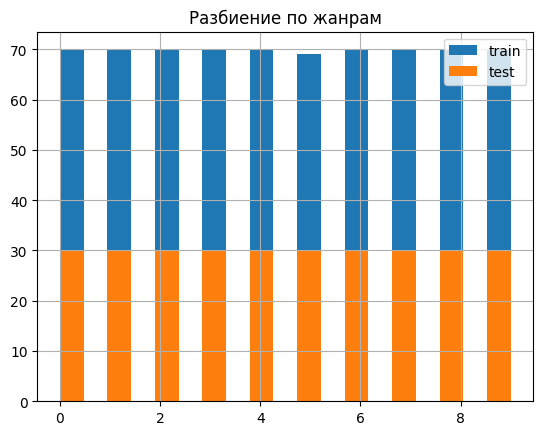

In [64]:
import matplotlib.pyplot as plt

plt.hist([elem['genre'] for elem in str_train_data], 19, label='train')
plt.hist([elem['genre'] for elem in str_test_data], 19, label='test')
plt.legend()
plt.title('Разбиение по жанрам')
plt.grid()
plt.show()

In [65]:
X_train = []
X_test = []
y_train = []
y_test = []
for el in str_train_data:
  y_train.append(el['genre'])
  X_train.append(el['features'])

for el in str_test_data:
  y_test.append(el['genre'])
  X_test.append(el['features'])

### Normalizing

In [66]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

#### 400(0.95)


In [67]:
pca_400 = PCA(n_components=400, svd_solver='full')
X_full_400 = pca_400.fit(X_train).transform(X_train)
X_full_400

array([[-2.50367796,  2.5842004 , -1.65917901, ..., -0.02978906,
        -0.44314962, -0.3509325 ],
       [ 6.21002884, -0.40001857, -2.05771137, ..., -0.01168314,
         0.01646411, -0.09201   ],
       [ 5.34359695, -0.08573523, -0.26957381, ...,  0.1110107 ,
        -0.23850814,  0.10002051],
       ...,
       [-4.67818569,  1.00361515,  1.16826633, ...,  0.28208087,
         0.06410641, -0.32949715],
       [-2.38063292,  0.55808263,  1.10924233, ..., -0.48728087,
        -0.32544234,  0.21478515],
       [-0.19339348, -4.87777163,  0.76829636, ..., -0.33012372,
        -0.20579654, -0.09987335]])

In [68]:
explained_variance = np.round(np.cumsum(pca_400.explained_variance_ratio_),3)
explained_variance

array([0.147, 0.215, 0.251, 0.277, 0.3  , 0.32 , 0.34 , 0.356, 0.37 ,
       0.384, 0.396, 0.407, 0.416, 0.426, 0.435, 0.443, 0.451, 0.459,
       0.466, 0.473, 0.48 , 0.486, 0.492, 0.498, 0.503, 0.508, 0.513,
       0.518, 0.523, 0.528, 0.532, 0.536, 0.541, 0.545, 0.549, 0.553,
       0.557, 0.56 , 0.564, 0.568, 0.571, 0.575, 0.578, 0.582, 0.585,
       0.589, 0.592, 0.595, 0.598, 0.601, 0.604, 0.607, 0.61 , 0.613,
       0.616, 0.618, 0.621, 0.624, 0.626, 0.629, 0.632, 0.634, 0.637,
       0.639, 0.642, 0.644, 0.646, 0.649, 0.651, 0.653, 0.656, 0.658,
       0.66 , 0.662, 0.664, 0.667, 0.669, 0.671, 0.673, 0.675, 0.677,
       0.679, 0.681, 0.683, 0.685, 0.687, 0.689, 0.691, 0.692, 0.694,
       0.696, 0.698, 0.7  , 0.702, 0.703, 0.705, 0.707, 0.709, 0.711,
       0.712, 0.714, 0.716, 0.717, 0.719, 0.721, 0.722, 0.724, 0.726,
       0.727, 0.729, 0.73 , 0.732, 0.733, 0.735, 0.737, 0.738, 0.74 ,
       0.741, 0.743, 0.744, 0.745, 0.747, 0.748, 0.75 , 0.751, 0.753,
       0.754, 0.755,

In [69]:
X_test_400 = pca_400.transform(X_test)

##### Log regression

In [70]:
basic = LogisticRegression(multi_class="multinomial", random_state=111, max_iter=1000).fit(X_full_400, y_train)
y_pred = basic.predict(X_test_400)
f1_score(y_pred, y_test, average='weighted')

0.811652346799089

##### SVM

In [71]:
best_model = SVC(C= 100, class_weight='balanced', kernel='poly', random_state = 111).fit(X_full_400, y_train)
y_pred = best_model.predict(X_test_400)
f1_score(y_test, y_pred, average='weighted')

0.6475067852802547

##### Dec tree

In [72]:
dt3 = DecisionTreeClassifier(random_state=111, criterion='entropy', class_weight='balanced').fit(X_full_400, y_train)
y_pred = dt3.predict(X_test_400)
f1_score(y_test, y_pred, average='weighted')

0.43353744324732246

### Подбор параметров SVM

In [73]:
tuned_parameters = [{'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
            'C': [1, 10, 100, 1000], 'class_weight': [None, 'balanced'], 'random_state':[111]}]



cv_svm = GridSearchCV(SVC(), tuned_parameters, refit=True, verbose=3).fit(X_full_400, y_train)
cv_svm.best_params_

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 1/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.700 total time=   0.1s
[CV 2/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.750 total time=   0.1s
[CV 3/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.729 total time=   0.1s
[CV 4/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.750 total time=   0.1s
[CV 5/5] END C=1, class_weight=None, gamma=1, kernel=linear, random_state=111;, score=0.799 total time=   0.1s
[CV 1/5] END C=1, class_weight=None, gamma=1, kernel=poly, random_state=111;, score=0.586 total time=   0.1s
[CV 2/5] END C=1, class_weight=None, gamma=1, kernel=poly, random_state=111;, score=0.643 total time=   0.1s
[CV 3/5] END C=1, class_weight=None, gamma=1, kernel=poly, random_state=111;, score=0.621 total time=   0.1s
[CV 4/5] END C=1, class_weight=None, gamma=1, kernel=po

{'C': 10,
 'class_weight': None,
 'gamma': 0.001,
 'kernel': 'rbf',
 'random_state': 111}

In [74]:

best_model_svm = SVC(C= 10, class_weight=None, gamma = 0.001, kernel='rbf', random_state = 111).fit(X_full_400, y_train)
y_pred_svm_4 = best_model_svm.predict(X_test_400)
f1_score(y_test, y_pred_svm_4, average='weighted')

0.8122472754986654

### Подбор параметров Log Regr

In [75]:
tuned_parameters = [{'penalty': ['l2', 'l1'], 'class_weight' : ['balanced', None], 'solver': ['newton-cg', 'sag', 'saga', 'lbfgs'],
            'C': [1, 10, 100, 1000], 'random_state':[111], 'max_iter':[100]}]



cv_lr = GridSearchCV(LogisticRegression(), tuned_parameters, refit=True, verbose=3).fit(X_full_400, y_train)
cv_lr.best_params_

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.750 total time=   0.3s
[CV 2/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.786 total time=   0.3s
[CV 3/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.757 total time=   0.3s
[CV 4/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.707 total time=   0.2s
[CV 5/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=newton-cg;, score=0.770 total time=   0.2s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=sag;, score=0.771 total time=   1.6s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/5] END C=1, class_weight=balanced, max_iter=100, penalty=l2, random_state=111, solver=sag;, score=0.793 total time=   1.9s


...

[CV 4/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=saga;, score=0.714 total time=   4.0s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
120 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solve

[CV 5/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=saga;, score=0.763 total time=   4.9s
[CV 1/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s
[CV 2/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s
[CV 3/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s
[CV 4/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s
[CV 5/5] END C=1000, class_weight=None, max_iter=100, penalty=l1, random_state=111, solver=lbfgs;, score=nan total time=   0.0s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'C': 10,
 'class_weight': 'balanced',
 'max_iter': 100,
 'penalty': 'l2',
 'random_state': 111,
 'solver': 'lbfgs'}

In [76]:
best_model_lr = LogisticRegression(multi_class="multinomial", C = 1, class_weight = 'balanced', penalty='l2', random_state=111, solver = 'lbfgs', max_iter=1000).fit(X_full_400, y_train)
y_pred_lr_4 = best_model_lr.predict(X_test_400)
f1_score(y_pred_lr_4, y_test, average='weighted')

0.811652346799089

### Пoдбор параметров Dec Tree

In [77]:
tuned_parameters = [{'criterion':['gini', 'entropy', 'log_loss'], 'max_depth': range(3, 20), 'class_weight':['balanced', None]}]



cv_lr = GridSearchCV(DecisionTreeClassifier(), tuned_parameters, refit=True, verbose=3).fit(X_full_400, y_train)
cv_lr.best_params_

Fitting 5 folds for each of 102 candidates, totalling 510 fits
[CV 1/5] END class_weight=balanced, criterion=gini, max_depth=3;, score=0.371 total time=   0.1s
[CV 2/5] END class_weight=balanced, criterion=gini, max_depth=3;, score=0.371 total time=   0.1s
[CV 3/5] END class_weight=balanced, criterion=gini, max_depth=3;, score=0.379 total time=   0.1s
[CV 4/5] END class_weight=balanced, criterion=gini, max_depth=3;, score=0.429 total time=   0.1s
[CV 5/5] END class_weight=balanced, criterion=gini, max_depth=3;, score=0.367 total time=   0.1s
[CV 1/5] END class_weight=balanced, criterion=gini, max_depth=4;, score=0.436 total time=   0.1s
[CV 2/5] END class_weight=balanced, criterion=gini, max_depth=4;, score=0.464 total time=   0.1s
[CV 3/5] END class_weight=balanced, criterion=gini, max_depth=4;, score=0.386 total time=   0.1s
[CV 4/5] END class_weight=balanced, criterion=gini, max_depth=4;, score=0.486 total time=   0.1s
[CV 5/5] END class_weight=balanced, criterion=gini, max_depth=4;

{'class_weight': None, 'criterion': 'entropy', 'max_depth': 4}

In [78]:
dt3 = DecisionTreeClassifier(criterion='entropy', class_weight=None, max_depth=4, random_state=111).fit(X_full_400, y_train)
y_pred_dt_4 = dt3.predict(X_test_400)
f1_score(y_test, y_pred_dt_4, average='weighted')

0.4645636450270088

## Confusion matrix&metrics

In [79]:
# вывести имена классов

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

### SVM


Accuracy: 0.07
Precision: 0.06417249946061199
Recall: 0.07
F1 Score: 0.06636431457605084


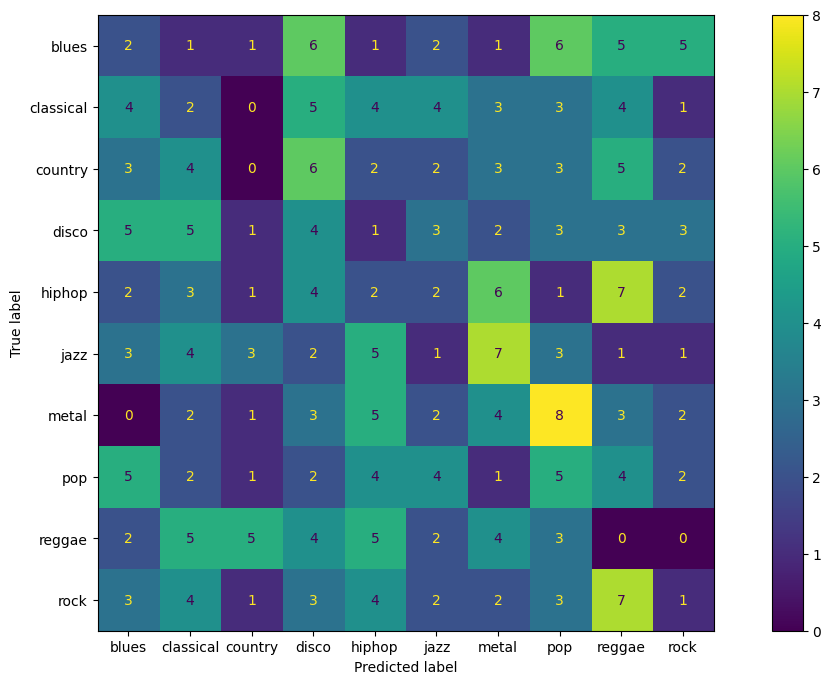

In [118]:
accuracy = accuracy_score(y_test, y_pred_svm_1)
precision = precision_score(y_test, y_pred_svm_1, average='weighted')
recall = recall_score(y_test, y_pred_svm_1, average='weighted')
f1 = f1_score(y_test, y_pred_svm_1, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


fig, ax = plt.subplots(figsize=(15, 8))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_1, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

Accuracy: 0.08666666666666667
Precision: 0.07917853935516977
Recall: 0.08666666666666667
F1 Score: 0.07669510739866858


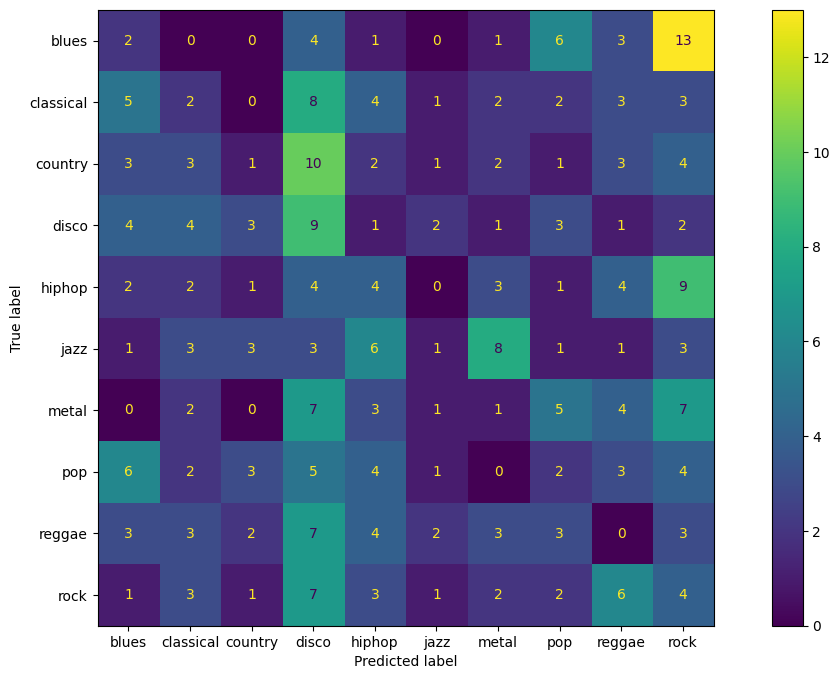

In [119]:
accuracy = accuracy_score(y_test, y_pred_svm_2)
precision = precision_score(y_test, y_pred_svm_2, average='weighted')
recall = recall_score(y_test, y_pred_svm_2, average='weighted')
f1 = f1_score(y_test, y_pred_svm_2, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_2, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

Accuracy: 0.06333333333333334
Precision: 0.06273332901252812
Recall: 0.06333333333333334
F1 Score: 0.061981026341373244


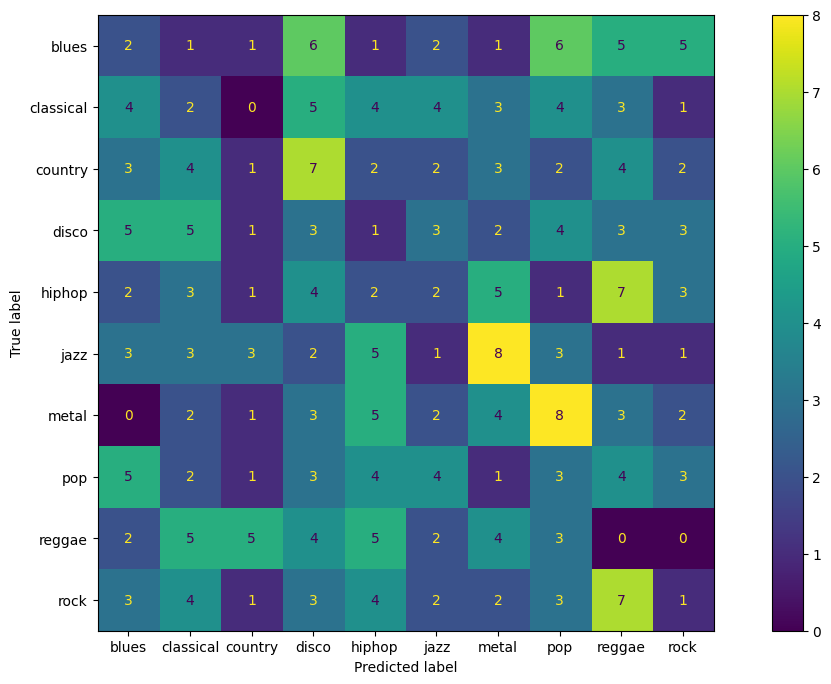

In [120]:
accuracy = accuracy_score(y_test, y_pred_svm_3)
precision = precision_score(y_test, y_pred_svm_3, average='weighted')
recall = recall_score(y_test, y_pred_svm_3, average='weighted')
f1 = f1_score(y_test, y_pred_svm_3, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_3, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

Accuracy: 0.8166666666666667
Precision: 0.8291052077585652
Recall: 0.8166666666666667
F1 Score: 0.8122472754986654


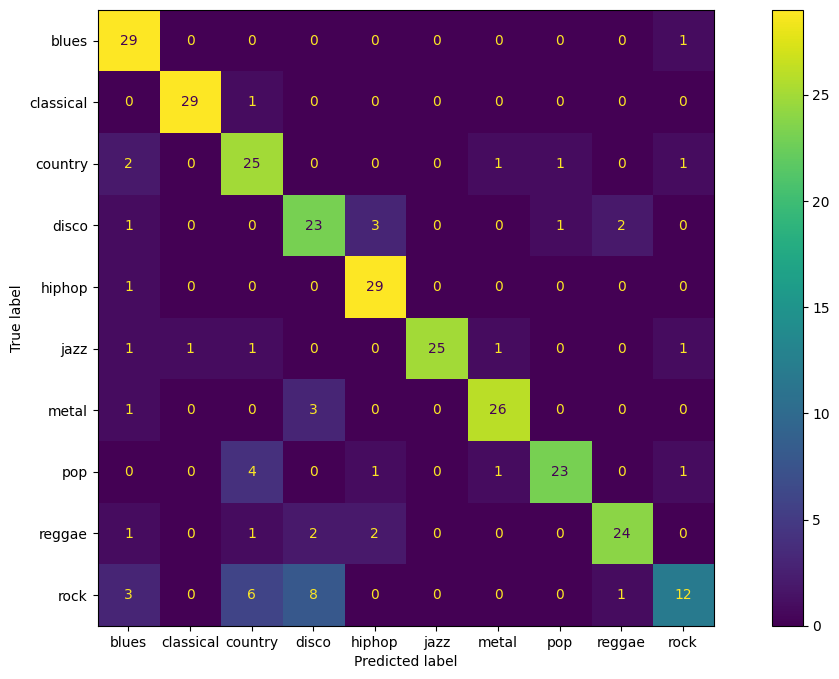

In [121]:
accuracy = accuracy_score(y_test, y_pred_svm_4)
precision = precision_score(y_test, y_pred_svm_4, average='weighted')
recall = recall_score(y_test, y_pred_svm_4, average='weighted')
f1 = f1_score(y_test, y_pred_svm_4, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_4, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

### Log Regr

Accuracy: 0.06333333333333334
Precision: 0.059315272636450755
Recall: 0.06333333333333334
F1 Score: 0.06062931584617805


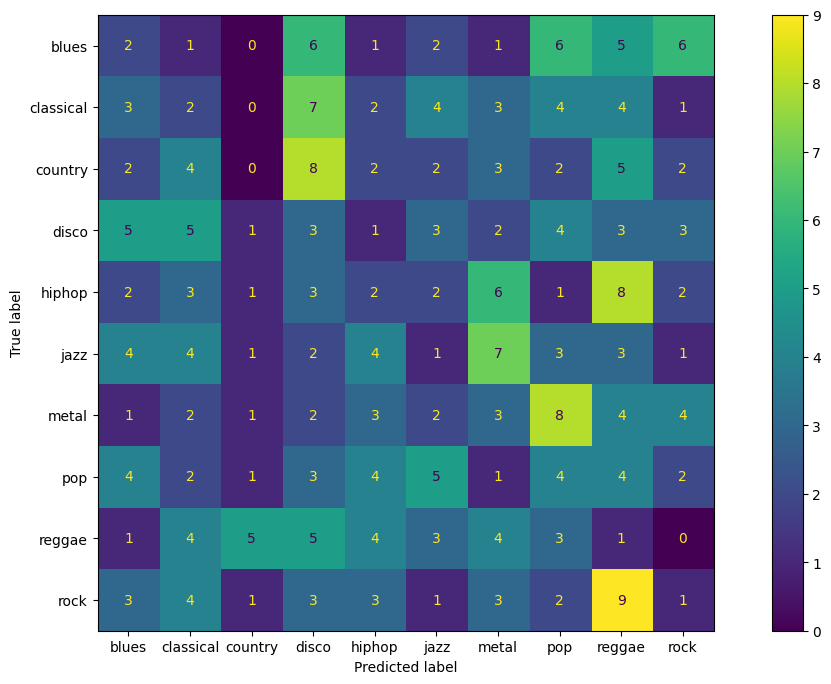

In [122]:
accuracy = accuracy_score(y_test, y_pred_lr_1)
precision = precision_score(y_test, y_pred_lr_1, average='weighted')
recall = recall_score(y_test, y_pred_lr_1, average='weighted')
f1 = f1_score(y_test, y_pred_lr_1, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_1, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

Accuracy: 0.06333333333333334
Precision: 0.06040447485608777
Recall: 0.06333333333333334
F1 Score: 0.061118044451953006


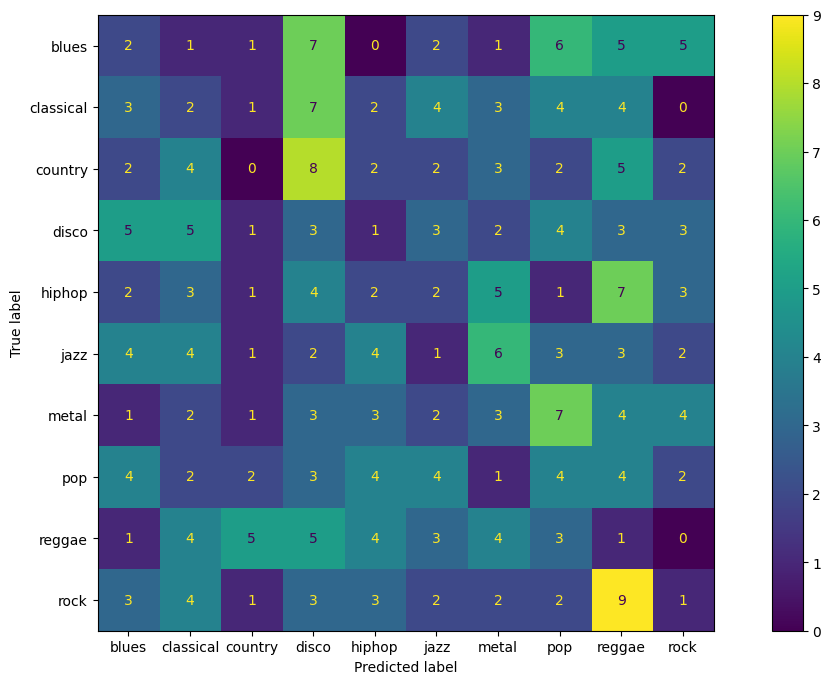

In [123]:
accuracy = accuracy_score(y_test, y_pred_lr_2)
precision = precision_score(y_test, y_pred_lr_2, average='weighted')
recall = recall_score(y_test, y_pred_lr_2, average='weighted')
f1 = f1_score(y_test, y_pred_lr_2, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_2, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

Accuracy: 0.06333333333333334
Precision: 0.05986096637131106
Recall: 0.06333333333333334
F1 Score: 0.06077262075774924


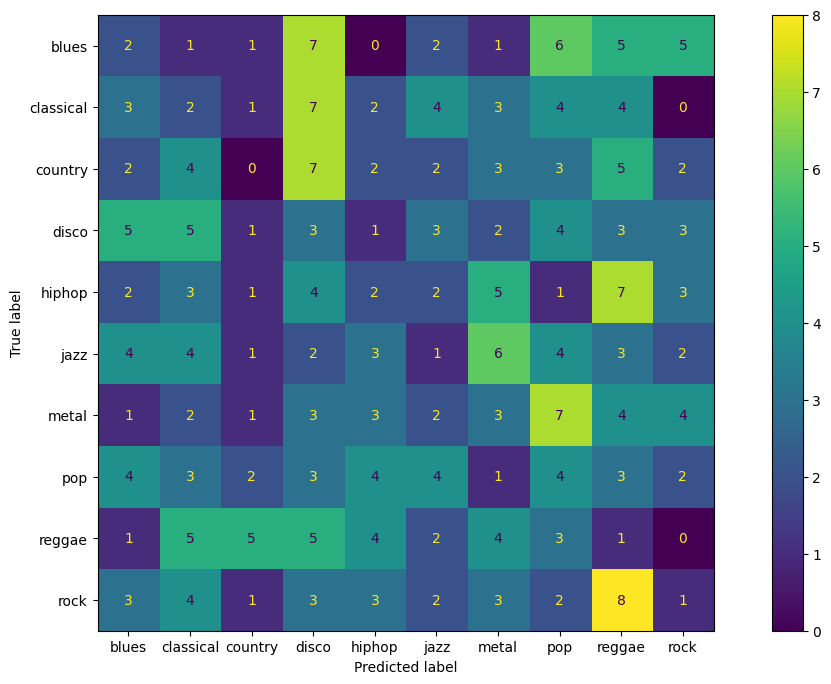

In [124]:
accuracy = accuracy_score(y_test, y_pred_lr_3)
precision = precision_score(y_test, y_pred_lr_3, average='weighted')
recall = recall_score(y_test, y_pred_lr_3, average='weighted')
f1 = f1_score(y_test, y_pred_lr_3, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_3, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

Accuracy: 0.8066666666666666
Precision: 0.8114076785853351
Recall: 0.8066666666666666
F1 Score: 0.8016809865342442


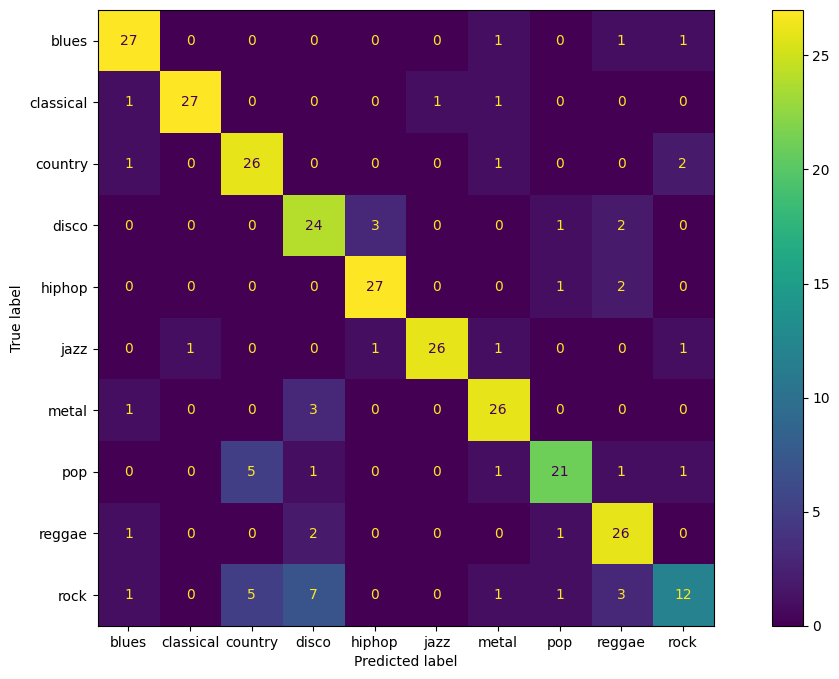

In [125]:
accuracy = accuracy_score(y_test, y_pred_lr_4)
precision = precision_score(y_test, y_pred_lr_4, average='weighted')
recall = recall_score(y_test, y_pred_lr_4, average='weighted')
f1 = f1_score(y_test, y_pred_lr_4, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_4, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

### Dec Tree

Accuracy: 0.10666666666666667
Precision: 0.09100935385845477
Recall: 0.10666666666666667
F1 Score: 0.0734996647515351


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


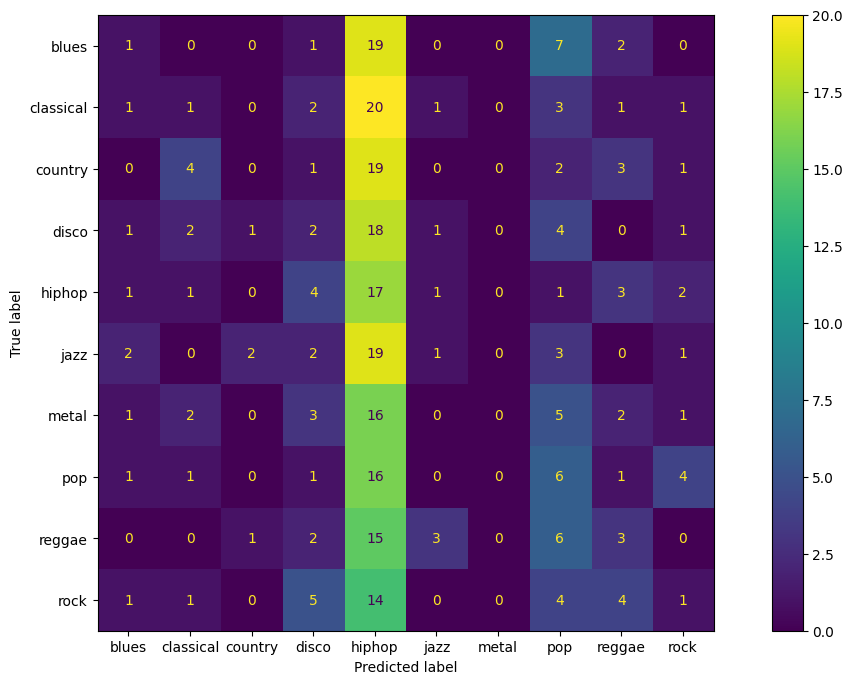

In [126]:
accuracy = accuracy_score(y_test, y_pred_dt_1)
precision = precision_score(y_test, y_pred_dt_1, average='weighted')
recall = recall_score(y_test, y_pred_dt_1, average='weighted')
f1 = f1_score(y_test, y_pred_dt_1, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_1, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

Accuracy: 0.07333333333333333
Precision: 0.07596619559777454
Recall: 0.07333333333333333
F1 Score: 0.07278416066666746


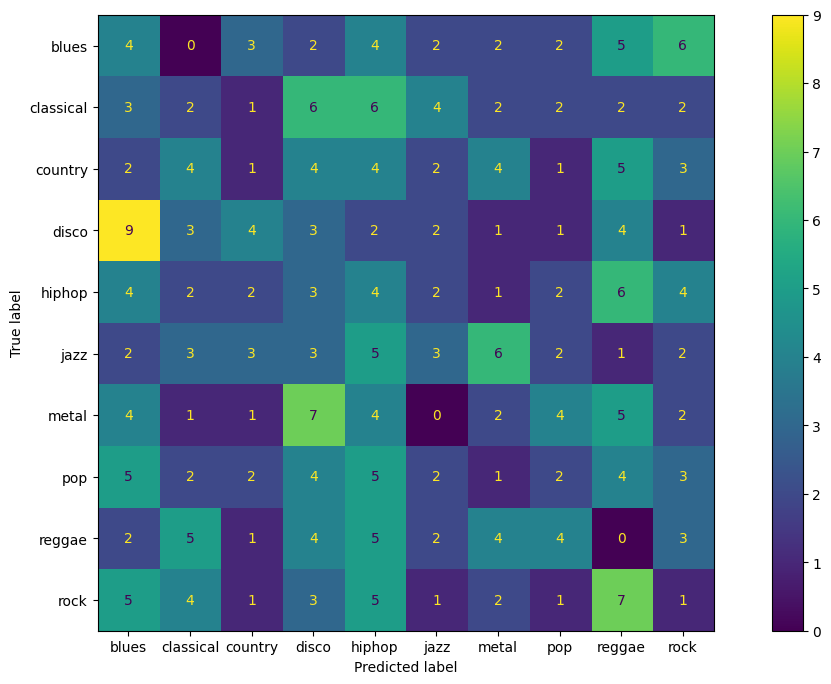

In [127]:
accuracy = accuracy_score(y_test, y_pred_dt_2)
precision = precision_score(y_test, y_pred_dt_2, average='weighted')
recall = recall_score(y_test, y_pred_dt_2, average='weighted')
f1 = f1_score(y_test, y_pred_dt_2, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_2, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

Accuracy: 0.09666666666666666
Precision: 0.0965197586133196
Recall: 0.09666666666666666
F1 Score: 0.08575800834735511


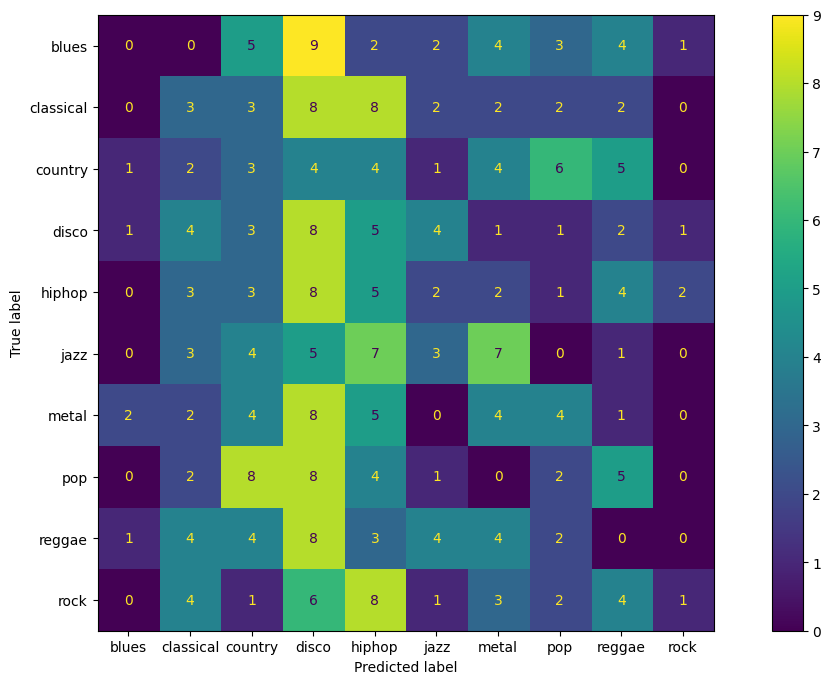

In [129]:
accuracy = accuracy_score(y_test, y_pred_dt_3)
precision = precision_score(y_test, y_pred_dt_3, average='weighted')
recall = recall_score(y_test, y_pred_dt_3, average='weighted')
f1 = f1_score(y_test, y_pred_dt_3, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_3, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy: 0.49
Precision: 0.471452822539779
Recall: 0.49
F1 Score: 0.4645636450270088


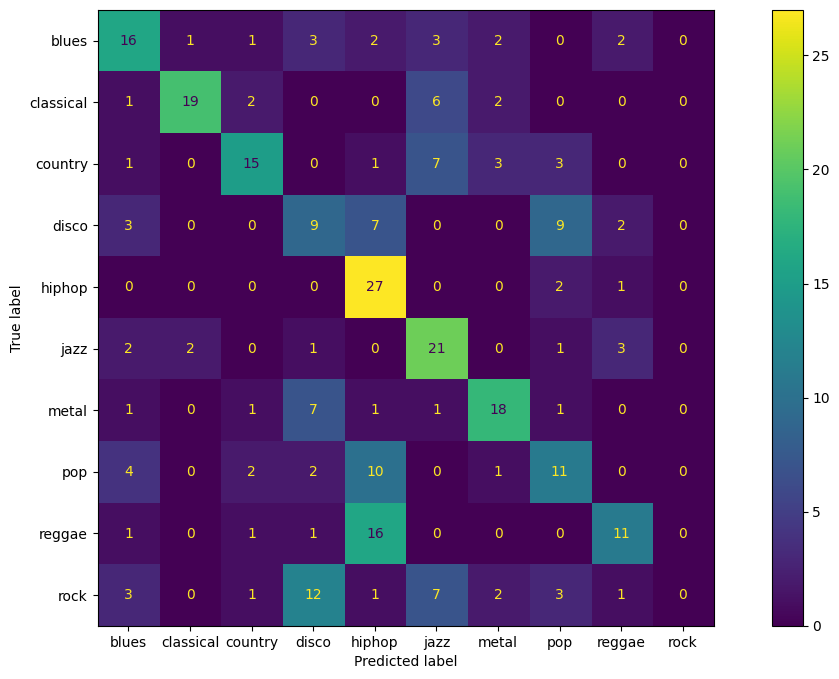

In [130]:
accuracy = accuracy_score(y_test, y_pred_dt_4)
precision = precision_score(y_test, y_pred_dt_4, average='weighted')
recall = recall_score(y_test, y_pred_dt_4, average='weighted')
f1 = f1_score(y_test, y_pred_dt_4, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_4, ax=ax, display_labels=['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])